In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from lmfit.models import GaussianModel
import matplotlib as m

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

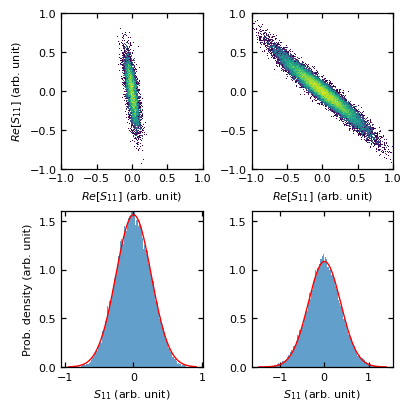

0.6699999999999999 0.6799999999999999


In [104]:
header = "C:/Users/qipe/Documents/K_Sunada/result/CDK184/"
vac_tx = "/2025-08-13/2025-08-13T092557_150872b0-i0_JPA_vac_squeeze"
dd_tx = datadict_from_hdf5(header + vac_tx +"/data")

pump_amplitude_tx = dd_tx["pump_amplitude"]["values"]
s11_tx = dd_tx["s11"]["values"]
id_tx =-4
s_11_tx = s11_tx[id_tx]
s11_pca_tx = PCA_transform(s_11_tx.real, s_11_tx.imag)[0]

vac_rx = "/2025-08-13/2025-08-13T102620_84577147-i0_JPA_vac_squeeze"
dd_rx = datadict_from_hdf5(header + vac_rx +"/data")

pump_amplitude_rx = dd_rx["pump_amplitude"]["values"]
s11_rx = dd_rx["s11"]["values"]
id_rx = -3
s_11_rx = s11_rx[id_rx]
s11_pca_rx = PCA_transform(s_11_rx.real, s_11_rx.imag)[0]

fig, ax = plt.subplots(2, 2, figsize=(4,4), constrained_layout=True)
ax[0, 0].tick_params(axis="both", direction="in")
ax[0, 0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1, 0].tick_params(axis="both", direction="in")
ax[1, 0].tick_params(top=True, bottom=True, left=True, right=True)
ax[0, 1].tick_params(axis="both", direction="in")
ax[0, 1].tick_params(top=True, bottom=True, left=True, right=True)
ax[1, 1].tick_params(axis="both", direction="in")
ax[1, 1].tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

ax[0, 0].hist2d(s_11_tx.real/0.03, s_11_tx.imag/0.03, bins=200, cmin=1, norm=m.colors.LogNorm())
ax[0, 0].set_xlim(-1, 1)
ax[0, 0].set_ylim(-1, 1)
ax[0, 0].set_xlabel(r"$Re[S_{11}]$ (arb. unit)")
ax[0, 0].set_ylabel(r"$Re[S_{11}]$ (arb. unit)")

ax[0, 1].hist2d(s_11_rx.real/0.03, s_11_rx.imag/0.03, bins=200, cmin=1, norm=m.colors.LogNorm())
ax[0, 1].set_xlim(-1, 1)
ax[0, 1].set_ylim(-1, 1)
ax[0, 1].set_xlabel(r"$Re[S_{11}]$ (arb. unit)")

hist, bins = np.histogram(s11_pca_tx/0.03, bins=200, density=True)
model = GaussianModel()
params = model.guess(hist, x = bins[1:])
result = model.fit(hist, params, x = bins[1:])
ax[1, 0].hist(s11_pca_tx/0.03, bins=200, density=True, alpha=0.7)
ax[1, 0].set_ylim(0, 1.6)
ax[1, 0].set_ylabel(r"Prob. density (arb. unit)")
ax[1, 0].plot(bins[1:], result.best_fit, label="gaussian fit", color="red")
ax[1, 0].set_xlabel(r"$S_{11}$ (arb. unit)")

hist, bins = np.histogram(s11_pca_rx/0.03, bins=200, density=True)
model = GaussianModel()
params = model.guess(hist, x = bins[1:])
result = model.fit(hist, params, x = bins[1:])
ax[1, 1].hist(s11_pca_rx/0.03, bins=200, density=True, alpha=0.7)
ax[1, 1].set_ylim(0, 1.6)
ax[1, 1].plot(bins[1:], result.best_fit, label="gaussian fit", color="red")
ax[1, 1].set_xlabel(r"$S_{11}$ (arb. unit)")
plt.savefig("mas_figs/vac_squeeze.pdf",  bbox_inches="tight")
plt.show()
print(pump_amplitude_tx[-4], pump_amplitude_tx[-3])

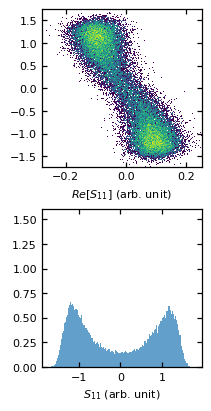

0.72


In [103]:
header = "C:/Users/qipe/Documents/K_Sunada/result/CDK184/"
vac_tx = "/2025-08-13/2025-08-13T092429_e0b0d421-i0_JPA_vac_squeeze"
dd_tx = datadict_from_hdf5(header + vac_tx +"/data")

pump_amplitude_tx = dd_tx["pump_amplitude"]["values"]
s11_tx = dd_tx["s11"]["values"]
id_tx =-10
s_11_tx = s11_tx[id_tx]
s11_pca_tx = PCA_transform(s_11_tx.real, s_11_tx.imag)[0]

vac_rx = "/2025-08-13/2025-08-13T102620_84577147-i0_JPA_vac_squeeze"
dd_rx = datadict_from_hdf5(header + vac_rx +"/data")

pump_amplitude_rx = dd_rx["pump_amplitude"]["values"]
s11_rx = dd_rx["s11"]["values"]
id_rx = -1
s_11_rx = s11_rx[id_rx]
s11_pca_rx = PCA_transform(s_11_rx.real, s_11_rx.imag)[0]

fig, ax = plt.subplots(2, 1, figsize=(2,4), constrained_layout=True)
ax[0].tick_params(axis="both", direction="in")
ax[0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1].tick_params(axis="both", direction="in")
ax[1].tick_params(top=True, bottom=True, left=True, right=True)
# ax[0, 1].tick_params(axis="both", direction="in")
# ax[0, 1].tick_params(top=True, bottom=True, left=True, right=True)
# ax[1, 1].tick_params(axis="both", direction="in")
# ax[1, 1].tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

ax[0].hist2d(s_11_tx.real/0.03, s_11_tx.imag/0.03, bins=200, cmin=1, norm=m.colors.LogNorm())
# ax[0, 0].set_xlim(-1, 1)
# ax[0, 0].set_ylim(-1, 1)
ax[0].set_xlabel(r"$Re[S_{11}]$ (arb. unit)")
# ax[0].set_ylabel(r"$Re[S_{11}]$ (arb. unit)")

# ax[1].hist2d(s_11_rx.real/0.03, s_11_rx.imag/0.03, bins=200, cmin=1, norm=m.colors.LogNorm())
# # ax[0, 1].set_xlim(-1, 1)
# # ax[0, 1].set_ylim(-1, 1)
# ax[1].set_xlabel(r"$Re[S_{11}]$ (arb. unit)")

hist, bins = np.histogram(s11_pca_tx/0.03, bins=200, density=True)
model = GaussianModel()
params = model.guess(hist, x = bins[1:])
result = model.fit(hist, params, x = bins[1:])
ax[1].hist(s11_pca_tx/0.03, bins=200, density=True, alpha=0.7)
ax[1].set_ylim(0, 1.6)
# ax[1].set_ylabel(r"Prob. density (arb. unit)")
# ax[1].plot(bins[1:], result.best_fit, label="gaussian fit", color="red")
ax[1].set_xlabel(r"$S_{11}$ (arb. unit)")

# hist, bins = np.histogram(s11_pca_rx/0.03, bins=200, density=True)
# model = GaussianModel()
# params = model.guess(hist, x = bins[1:])
# result = model.fit(hist, params, x = bins[1:])
# ax[1, 1].hist(s11_pca_rx/0.03, bins=200, density=True, alpha=0.7)
# ax[1, 1].set_ylim(0, 1.6)
# ax[1, 1].plot(bins[1:], result.best_fit, label="gaussian fit", color="red")
# ax[1, 1].set_xlabel(r"$S_{11}$ (arb. unit)")
plt.savefig("mas_figs/vac_squeeze1.pdf",  bbox_inches="tight")
plt.show()
print(pump_amplitude_tx[-10])

phase optimization

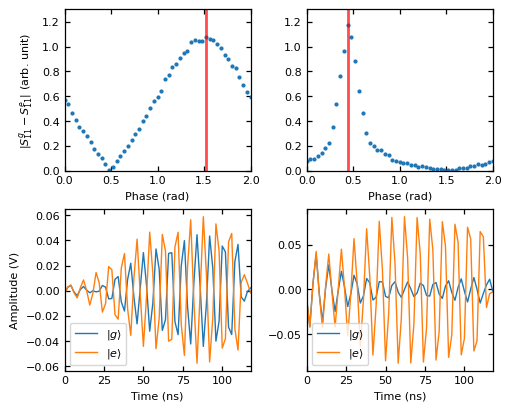

In [67]:
data_tx = "/2025-08-13/2025-08-13T093741_b89a6e2e-i1_JPA_phase_optimization_for_ge"  #10dB
dd_tx = datadict_from_hdf5(header + data_tx +"/data")
x_tx = dd_tx["phase"]["values"]
y_tx = dd_tx["distance"]["values"]
y_pca_tx = PCA_transform(y_tx.real, y_tx.imag)[0]

data_rx = "/2025-08-13/2025-08-13T104958_d19f514a-i1_JPA_phase_optimization_for_ge"  #10dB
dd_rx = datadict_from_hdf5(header + data_rx +"/data")
x_rx = dd_rx["phase"]["values"]
y_rx = dd_rx["distance"]["values"]
y_pca_rx = PCA_transform(y_rx.real, y_rx.imag)[0]

data_t ="/2025-08-13/2025-08-13T095617_51b25193-i2_readout_fidelity_threshold"
dd_t =datadict_from_hdf5(header + data_t +"/data")
time_t = dd_t["time"]["values"][0]
pulse_g_t = dd_t["pulse_g"]["values"][0]
pulse_e_t = dd_t["pulse_e"]["values"][0]

data_r ="/2025-08-13/2025-08-13T105133_0a05bf55-i2_readout_fidelity_threshold"
dd_r =datadict_from_hdf5(header + data_r +"/data")
time_r = dd_r["time"]["values"][0]
pulse_g_r = dd_r["pulse_g"]["values"][0]
pulse_e_r = dd_r["pulse_e"]["values"][0]


fig, ax = plt.subplots(2, 2, figsize=(5,4), constrained_layout=True)
ax[0, 0].tick_params(axis="both", direction="in")
ax[0, 0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1, 0].tick_params(axis="both", direction="in")
ax[1, 0].tick_params(top=True, bottom=True, left=True, right=True)
ax[0, 1].tick_params(axis="both", direction="in")
ax[0, 1].tick_params(top=True, bottom=True, left=True, right=True)
ax[1, 1].tick_params(axis="both", direction="in")
ax[1, 1].tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.


ax[0, 0].plot(x_tx, np.abs(y_tx)/0.03, 'o')
ax[0, 0].vlines(1.52, 0, 1.3, color='r', lw=2, alpha=0.7)
ax[0, 0].set_xlim(0, 2)
ax[0, 0].set_ylim(-0., 1.3)
ax[0, 0].set_xlabel(r"Phase (rad)")
ax[0, 0].set_ylabel(r"$|S_{11}^g-S_{11}^e|$ (arb. unit)")

ax[0, 1].plot(x_rx, np.abs(y_rx)/0.03, 'o')
ax[0, 1].vlines(0.44, 0, 1.3, color='r', lw=2, alpha=0.7)
ax[0, 1].set_xlim(0, 2)
ax[0, 1].set_ylim(-0., 1.3)
ax[0, 1].set_xlabel(r"Phase (rad)")


ax[1, 0].plot(time_t, pulse_g_t,  label = r"$|g\rangle$")
ax[1, 0].plot(time_t, pulse_e_t,  label = r"$|e\rangle$")
ax[1, 0].set_xlim(0, time_t[-1])
ax[1, 0].set_ylabel(r"Amplitude (V)")
ax[1, 0].legend()
ax[1, 0].set_xlabel(r"Time (ns)")

ax[1, 1].plot(time_r, pulse_g_r,  label = r"$|g\rangle$")
ax[1, 1].plot(time_r, pulse_e_r,  label = r"$|e\rangle$")
ax[1, 1].set_xlim(0, time_r[-1])
ax[1, 1].legend()
ax[1, 1].set_xlabel(r"Time (ns)")
plt.savefig("mas_figs/pump_phase.pdf",  bbox_inches="tight")
plt.show()

readout fidelity

readout fidelity for g_t: 0.9978101575002105
readout fidelity for e_t: 0.9900470860236276
readout fidelity for g_r: 0.9978101575002105
readout fidelity for e_r: 0.9900470860236276
QND fidelity for g_t: 0.9984664287307606
QND fidelity for e_t: 0.983274907008483
QND fidelity for g_r: 0.9926005401605683
QND fidelity for e_r: 0.9754072681704261


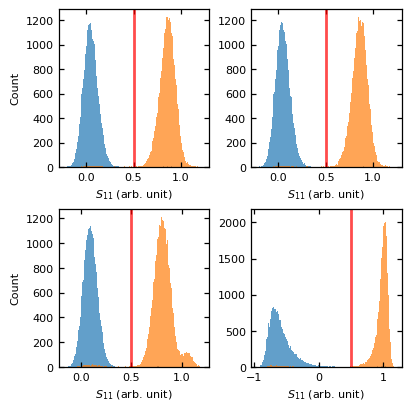

In [ ]:
data_tx = "/2025-08-13/2025-08-13T100839_0c37f003-i3_readout_fidelity" #0.7
dd_tx =datadict_from_hdf5(header + data_tx +"/data")
signal_g_tx = dd_tx["signal_g"]["values"].ravel()
signal_e_tx = dd_tx["signal_e"]["values"].ravel()

data_rx = "/2025-08-13/2025-08-13T105252_394e37cc-i3_readout_fidelity"  #0.7
dd_rx =datadict_from_hdf5(header + data_tx +"/data")
signal_g_rx = dd_rx["signal_g"]["values"].ravel()
signal_e_rx = dd_rx["signal_e"]["values"].ravel()

data_t = "/2025-08-13/2025-08-13T102213_f11d00cd-i4_QND_fidelity" #0.7
dd_t =datadict_from_hdf5(header + data_t +"/data")
signal_g_t = dd_t["signal_g"]["values"].ravel()
signal_e_t = dd_t["signal_e"]["values"].ravel()


data_r = "/2025-08-13/2025-08-13T135900_39ef73d6-i4_QND_fidelity" #0.7
dd_r =datadict_from_hdf5(header + data_r +"/data")
signal_g_r = dd_r["signal_g"]["values"].ravel()
signal_e_r = dd_r["signal_e"]["values"].ravel()

fig, ax = plt.subplots(2, 2, figsize=(4,4), constrained_layout=True)
ax[0, 0].tick_params(axis="both", direction="in")
ax[0, 0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1, 0].tick_params(axis="both", direction="in")
ax[1, 0].tick_params(top=True, bottom=True, left=True, right=True)
ax[0, 1].tick_params(axis="both", direction="in")
ax[0, 1].tick_params(top=True, bottom=True, left=True, right=True)
ax[1, 1].tick_params(axis="both", direction="in")
ax[1, 1].tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

ax[0, 0].hist(signal_g_tx, bins=200, alpha=0.7, log=0, label= "g")
ax[0, 0].hist(signal_e_tx, bins=200, alpha=0.7, label= "e")
# ax[0, 0].set_xlim(0, 2)
# ax[0, 0].set_ylim(-0., 1.3)
ax[0, 0].set_xlabel(r"$S_{11}$ (arb. unit)")
ax[0, 0].set_ylabel(r"Count")
# ax[0, 0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.0))

ax[0, 1].hist(signal_g_rx, bins=200, alpha=0.7, log=0, label= "g")
ax[0, 1].hist(signal_e_rx, bins=200, alpha=0.7, label= "e")
# ax[0, 1].set_xlim(0, 2)
# ax[0, 1].set_ylim(-0., 1.3)
ax[0, 1].set_xlabel(r"$S_{11}$ (arb. unit)")
# ax[0, 1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.0))

ax[1, 0].hist(signal_g_t, bins=200, alpha=0.7, log=0, label= "g")
ax[1, 0].hist(signal_e_t, bins=200, alpha=0.7, label= "e")
# ax[1, 0].set_xlim(0, 2)
# ax[1, 0].set_ylim(-0., 1.3)
ax[1, 0].set_xlabel(r"$S_{11}$ (arb. unit)")
ax[1, 0].set_ylabel(r"Count")
# ax[1, 0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.0))

ax[1, 1].hist(signal_g_r, bins=200, alpha=0.7, log=0, label= "g")
ax[1, 1].hist(signal_e_r, bins=200, alpha=0.7, label= "e")
# ax[1, 1].set_xlim(0, 2)
# ax[1, 1].set_ylim(-0., 1.3)
ax[1, 1].set_xlabel(r"$S_{11}$ (arb. unit)")
# ax[1, 1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.0))


print(f"readout fidelity for g_t: {1- len([el for el in signal_g_tx if el>0.5])/len(signal_g_tx)}")
print(f"readout fidelity for e_t: {1- len([el for el in signal_e_tx if el<0.5])/len(signal_e_tx)}")
print(f"readout fidelity for g_r: {1- len([el for el in signal_g_rx if el>0.5])/len(signal_g_rx)}")
print(f"readout fidelity for e_r: {1- len([el for el in signal_e_rx if el<0.5])/len(signal_e_rx)}")

print(f"QND fidelity for g_t: {1- len([el for el in signal_g_t if el>0.5])/len(signal_g_t)}")
print(f"QND fidelity for e_t: {1- len([el for el in signal_e_t if el<0.5])/len(signal_e_t)}")
print(f"QND fidelity for g_r: {1- len([el for el in signal_g_r if el>0.5])/len(signal_g_r)}")
print(f"QND fidelity for e_r: {1- len([el for el in signal_e_r if el<0.5])/len(signal_e_r)}")
threshold=0.5
ax[0, 0].axvline(threshold, color='r', lw=2, alpha=0.7)
ax[0, 1].axvline(threshold, color='r', lw=2, alpha=0.7)
ax[1, 0].axvline(threshold, color='r', lw=2, alpha=0.7)
ax[1, 1].axvline(threshold, color='r', lw=2, alpha=0.7)
plt.savefig("mas_figs/readout_fidelity.pdf",  bbox_inches="tight")
plt.show()

In [105]:
(0.9978101575002105+ 0.9900470860236276)/2, (0.9978101575002105+0.9900470860236276)/2, (0.9984664287307606+0.983274907008483)/2, (0.9926005401605683+0.9754072681704261)/2

(0.993928621761919, 0.993928621761919, 0.9908706678696217, 0.9840039041654972)

QND fidelity for g: 0.9984664287307606
QND fidelity for e: 0.983274907008483


Text(0, 0.5, '$S_{11}$ (arb. u.)')

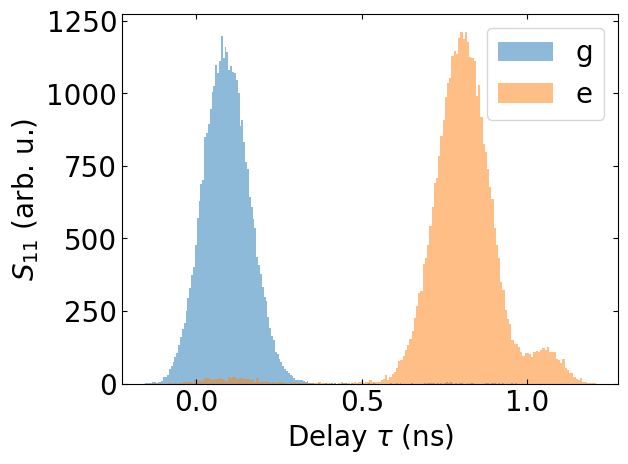

In [33]:
data = "/2025-08-13/2025-08-13T102213_f11d00cd-i4_QND_fidelity" #0.7
dd =datadict_from_hdf5(header + data +"/data")
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()

plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.hist(signal_g, bins=200, alpha=0.5, log=0, label= "g")
plt.hist(signal_e, bins=200, alpha=0.5, label= "e")
print(f"QND fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g)}")
print(f"QND fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e)}")

plt.title("")
plt.legend()
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")